# Supply Chain Analysis — Python & Pandas

**Dataset:** 100 SKUs | 3 Product Lines | 5 Suppliers  
**Tools:** Python, pandas, matplotlib  
**Goal:** Identify operational risks across product lines, suppliers, and logistics to support data-driven procurement decisions.

---

## Analysis 1 — Revenue by Product Type

**Question:** Which product line generates the most revenue?  
**Why it matters:** Revenue distribution guides inventory prioritization and resource allocation.

In [29]:
df = pd.read_csv("/content/kaggle database.csv")

## Analysis 2 — Low Stock Warning

**Question:** Which products are at risk of stockout?  
**Why it matters:** Stockouts in high-revenue lines directly impact sales and customer satisfaction.

Low stock products: 27
   Product type    SKU  Stock levels
68     haircare  SKU68             0
2      haircare   SKU2             1
34     skincare  SKU34             1
16     skincare  SKU16             2
47     skincare  SKU47             4
33    cosmetics  SKU33             4
24     haircare  SKU24             4
8     cosmetics   SKU8             5
57     haircare  SKU57             5
87     haircare  SKU87             5
78     haircare  SKU78             5
4      skincare   SKU4             5
31     skincare  SKU31             6
15     skincare  SKU15             9
70     haircare  SKU70            10
18     haircare  SKU18            10
58     skincare  SKU58            10
6      skincare   SKU6            11
67     skincare  SKU67            12
44    cosmetics  SKU44            13
66     skincare  SKU66            13
9      skincare   SKU9            14
95     haircare  SKU95            15
85    cosmetics  SKU85            15
75     skincare  SKU75            16
73    cosmetics

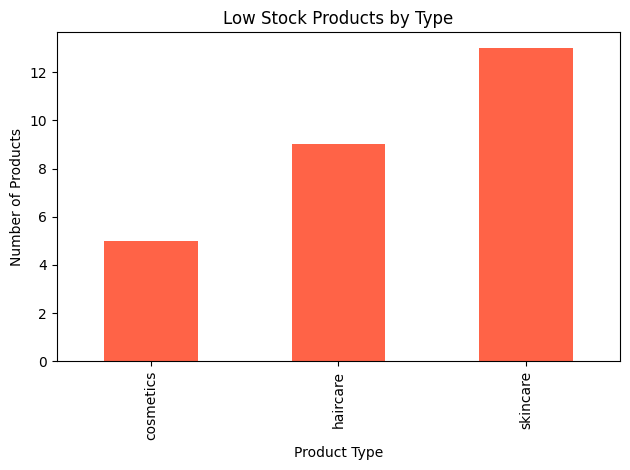

In [30]:
low_stock = df[df['Stock levels'] < 20]
print(f"Low stock products: {len(low_stock)}")
print(low_stock[['Product type', 'SKU', 'Stock levels']].sort_values('Stock levels'))

low_stock.groupby('Product type')['SKU'].count().plot(kind='bar', color='tomato')
plt.title('Low Stock Products by Type')
plt.ylabel('Number of Products')
plt.xlabel('Product Type')
plt.tight_layout()
plt.show()

## Analysis 3 — Defect Rate by Supplier

**Question:** Which supplier has the highest defect rate?  
**Why it matters:** High defect rates increase costs and signal quality control issues in the supply chain.

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64


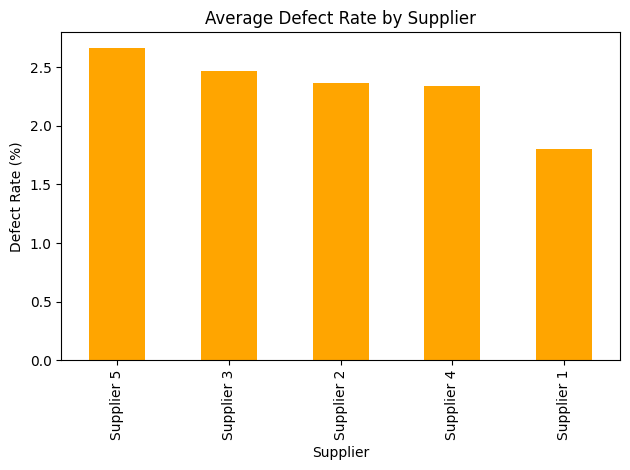

In [31]:
defect_by_supplier = df.groupby('Supplier name')['Defect rates'].mean().sort_values(ascending=False)
print(defect_by_supplier)

defect_by_supplier.plot(kind='bar', color='orange')
plt.title('Average Defect Rate by Supplier')
plt.ylabel('Defect Rate (%)')
plt.xlabel('Supplier')
plt.tight_layout()
plt.show()

## Analysis 4 — Cost by Transportation Mode

**Question:** Which transportation mode is most cost-efficient?  
**Why it matters:** Logistics cost directly affects margin. Identifying cheaper modes creates optimization opportunities.

Transportation modes
Air     561.712596
Road    553.385988
Rail    541.747556
Sea     417.819148
Name: Costs, dtype: float64


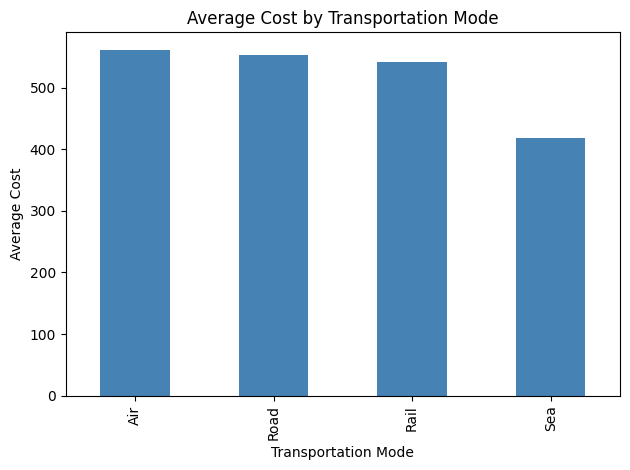

In [32]:
cost_by_transport = df.groupby('Transportation modes')['Costs'].mean().sort_values(ascending=False)
print(cost_by_transport)

cost_by_transport.plot(kind='bar', color='steelblue')
plt.title('Average Cost by Transportation Mode')
plt.ylabel('Average Cost')
plt.xlabel('Transportation Mode')
plt.tight_layout()
plt.show()

## Analysis 5 — Lead Time by Supplier

**Question:** Which supplier has the longest and most inconsistent lead time?  
**Why it matters:** Unpredictable lead times make inventory planning difficult and increase stockout risk.

               avg_lead  std_lead
Supplier name                    
Supplier 4         17.0       8.9
Supplier 1         16.8       8.6
Supplier 2         16.2       8.8
Supplier 5         14.7       9.6
Supplier 3         14.3       8.8


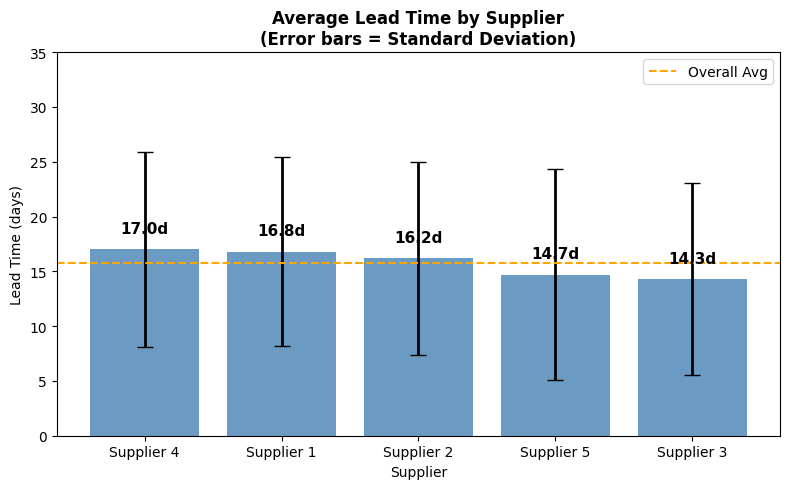

In [33]:
lead_by_supplier = df.groupby('Supplier name')['Lead times'].agg(
    avg_lead='mean', std_lead='std').round(1).sort_values('avg_lead', ascending=False)
print(lead_by_supplier)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(lead_by_supplier.index, lead_by_supplier['avg_lead'],
              color='steelblue', alpha=0.8,
              yerr=lead_by_supplier['std_lead'],
              capsize=6, error_kw={'color': 'tomato', 'linewidth': 2})
for bar, mean in zip(bars, lead_by_supplier['avg_lead']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{mean}d', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Average Lead Time by Supplier\n(Error bars = Standard Deviation)', fontweight='bold')
ax.set_xlabel('Supplier')
ax.set_ylabel('Lead Time (days)')
ax.set_ylim(0, 35)
ax.axhline(y=lead_by_supplier['avg_lead'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Overall Avg')
ax.legend()
plt.tight_layout()
plt.show()

## Analysis 6 — Shipping Cost vs Revenue

**Question:** What percentage of revenue is consumed by shipping costs?  
**Why it matters:** High shipping cost ratios reduce margin and signal inefficient logistics spend.

              avg_shipping  avg_revenue  avg_ratio_pct
Product type                                          
cosmetics            6.060     6212.356            0.1
haircare             5.908     5131.041            0.2
skincare             4.910     6040.704            0.1


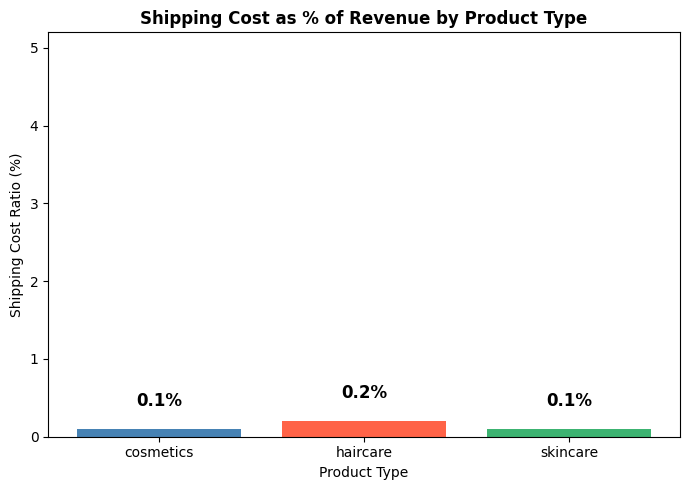

In [34]:
df['Shipping cost ratio'] = df['Shipping costs'] / df['Revenue generated']
shipping_ratio = df.groupby('Product type').agg(
    avg_shipping=('Shipping costs', 'mean'),
    avg_revenue=('Revenue generated', 'mean'),
    avg_ratio=('Shipping cost ratio', 'mean')).round(3)
shipping_ratio['avg_ratio_pct'] = (shipping_ratio['avg_ratio'] * 100).round(1)
print(shipping_ratio[['avg_shipping', 'avg_revenue', 'avg_ratio_pct']])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(shipping_ratio.index, shipping_ratio['avg_ratio_pct'],
              color=['steelblue', 'tomato', 'mediumseagreen'])
for bar, val in zip(bars, shipping_ratio['avg_ratio_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Shipping Cost as % of Revenue by Product Type', fontweight='bold')
ax.set_ylabel('Shipping Cost Ratio (%)')
ax.set_xlabel('Product Type')
ax.set_ylim(0, shipping_ratio['avg_ratio_pct'].max() + 5)
plt.tight_layout()
plt.show()

## Key Takeaways

- **Skincare** is the highest-revenue product line but faces the greatest stockout risk
- **Supplier 4** presents dual risk: longest lead time (17 days) and above-average defect rate
- **Supplier 5** has the highest defect rate — quality review recommended
- **Sea freight** offers the best cost efficiency at ~25% below air freight
- Shipping costs are well-controlled across all product lines (<0.2% of revenue)

Product type
skincare     241628.162133
haircare     174455.390606
cosmetics    161521.266001
Name: Revenue generated, dtype: float64


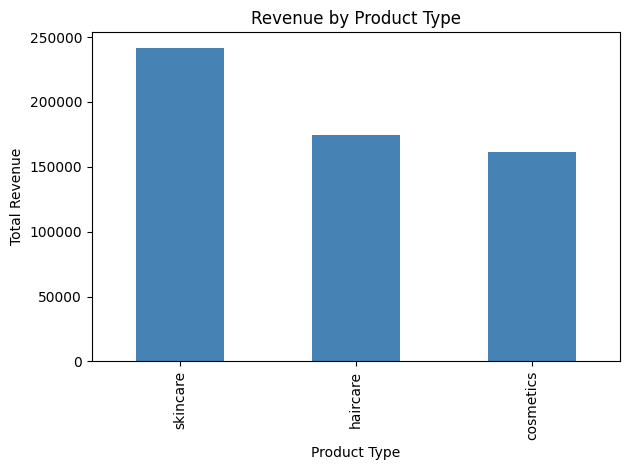

In [35]:
revenue_by_type = df.groupby('Product type')['Revenue generated'].sum().sort_values(ascending=False)
print(revenue_by_type)

revenue_by_type.plot(kind='bar', color='steelblue')
plt.title('Revenue by Product Type')
plt.ylabel('Total Revenue')
plt.xlabel('Product Type')
plt.tight_layout()
plt.show()